
<h3 style="
background-color:#1e1e1e;
color:#FFD700;
padding:6px 10px;
border-radius:6px;
">
1/ Data Collection
</h3>


In [210]:
import pandas as pd

In [211]:
import seaborn as sns

In [212]:
import matplotlib.pyplot as plt

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import StandardScaler

In [213]:
df = pd.read_csv(r"C:\Users\Youssef\Desktop\DEPI\Data Science Projects\7.Regression A.(2)\Students_Grades_Predictions.csv")


<h3 style="
background-color:#1e1e1e;
color:#FFD700;
padding:6px 10px;
border-radius:6px;
">
2/ Understanding the Data (EDA)
</h3>


In [214]:
df.head()

,StudentID,Name,Gender,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,ParentalSupport,FinalGrade,Study Hours,Attendance (%),Online Classes Taken
0,1.0,John,Male,85.0,15.0,78.0,1.0,High,80.0,4.8,59.0,False
1,2.0,Sarah,Female,90.0,20.0,85.0,2.0,Medium,87.0,2.2,70.0,True
2,3.0,Alex,Male,78.0,10.0,65.0,0.0,Low,68.0,4.6,92.0,False
3,4.0,Michael,Male,92.0,25.0,90.0,3.0,High,92.0,2.9,96.0,False
4,5.0,Emma,Female,NaN,18.0,82.0,2.0,Medium,85.0,4.1,97.0,True


⟹duplicated columns and Need Encoding Categorical Features

In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  960 non-null    float64
 1   Name                       966 non-null    object 
 2   Gender                     952 non-null    object 
 3   AttendanceRate             960 non-null    float64
 4   StudyHoursPerWeek          950 non-null    float64
 5   PreviousGrade              967 non-null    float64
 6   ExtracurricularActivities  957 non-null    float64
 7   ParentalSupport            978 non-null    object 
 8   FinalGrade                 960 non-null    float64
 9   Study Hours                976 non-null    float64
 10  Attendance (%)             959 non-null    float64
 11  Online Classes Taken       975 non-null    object 
dtypes: float64(8), object(4)
memory usage: 93.9+ KB


⟹Missing (Null) Values

In [216]:
df.describe()

,StudentID,AttendanceRate,StudyHoursPerWeek,PreviousGrade,ExtracurricularActivities,FinalGrade,Study Hours,Attendance (%)
count,960.000000,960.000000,950.000000,967.000000,957.000000,960.000000,976.000000,959.000000
mean,5416.019792,85.510417,17.630526,77.598759,1.520376,80.030208,2.406967,77.248175
std,2653.748319,7.332125,6.272132,10.006640,1.046439,9.493652,1.620267,19.298148
min,1.000000,70.000000,8.000000,60.000000,0.000000,62.000000,-5.000000,50.000000
25%,3113.500000,82.000000,12.000000,70.000000,1.000000,72.000000,1.200000,63.000000
50%,5396.500000,88.000000,18.000000,78.000000,1.000000,80.000000,2.500000,76.000000
75%,7754.750000,91.000000,22.000000,86.000000,2.000000,88.000000,3.700000,89.000000
max,9998.000000,95.000000,30.000000,90.000000,3.000000,92.000000,5.000000,200.000000


In [217]:
# Define Our Target
y = df['FinalGrade']

In [218]:
X = df.drop(['FinalGrade','StudentID','Name'], axis=1, errors='ignore')

In [219]:
# Splitting data to train and test using sklearn after shuffling (Mixing) it
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)

In [220]:
X_train.isnull().sum()

Gender                       43
AttendanceRate               34
StudyHoursPerWeek            42
PreviousGrade                25
ExtracurricularActivities    37
ParentalSupport              16
Study Hours                  21
Attendance (%)               31
Online Classes Taken         18
dtype: int64

In [221]:
X_test.isnull().sum()

Gender                        5
AttendanceRate                6
StudyHoursPerWeek             8
PreviousGrade                 8
ExtracurricularActivities     6
ParentalSupport               6
Study Hours                   3
Attendance (%)               10
Online Classes Taken          7
dtype: int64

In [222]:
num_cols = X_train.select_dtypes(include=['int64','float64']).columns

In [223]:
cat_cols = X_train.select_dtypes(include=['object','bool']).columns

In [224]:
# 2. Handle missing values
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object','bool']).columns

train_means = X_train[num_cols].mean()
train_modes = X_train[cat_cols].mode().iloc[0]

for col in num_cols:
    X_train[col] = X_train[col].fillna(train_means[col])
    X_test[col] = X_test[col].fillna(train_means[col])

for col in cat_cols:
    X_train[col] = X_train[col].fillna(train_modes[col])
    X_test[col] = X_test[col].fillna(train_modes[col])

C:\Users\Youssef\AppData\Local\Temp\ipykernel_3120\3431524557.py:13: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train[col] = X_train[col].fillna(train_modes[col])
C:\Users\Youssef\AppData\Local\Temp\ipykernel_3120\3431524557.py:14: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_test[col] = X_test[col].fillna(train_modes[col])


In [225]:
X_train.isnull().sum()

Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
Study Hours                  0
Attendance (%)               0
Online Classes Taken         0
dtype: int64

In [226]:
X_test.isnull().sum()

Gender                       0
AttendanceRate               0
StudyHoursPerWeek            0
PreviousGrade                0
ExtracurricularActivities    0
ParentalSupport              0
Study Hours                  0
Attendance (%)               0
Online Classes Taken         0
dtype: int64

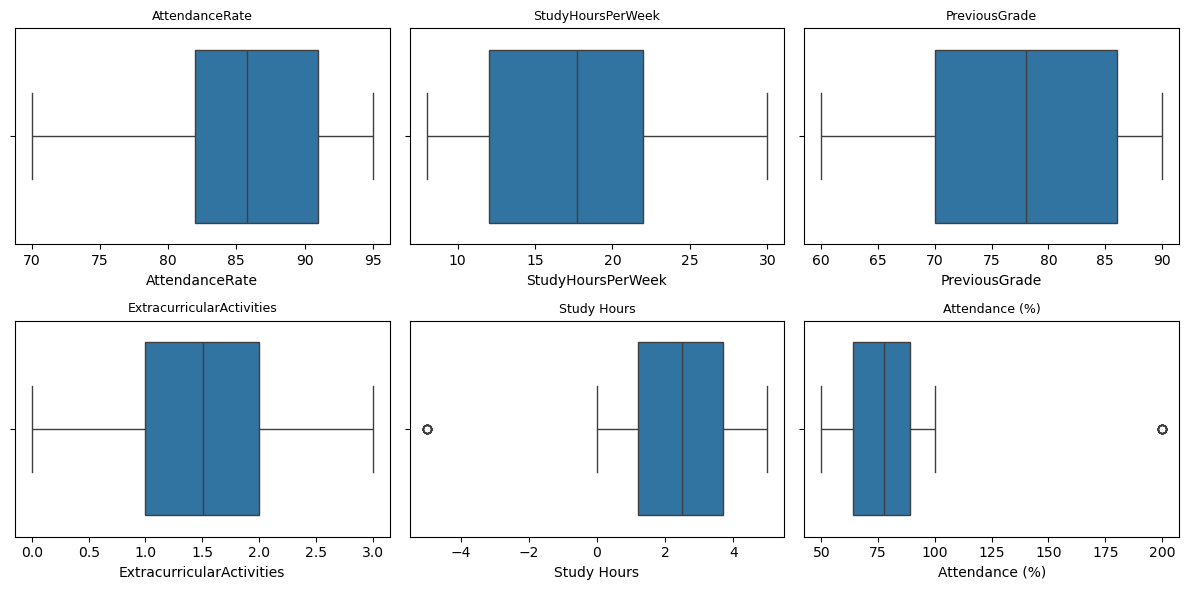

In [227]:
# Loop through numeric features and plot boxplots
# Select numeric features
# Select numeric features
numeric_features = X_train.select_dtypes(include=['int64','float64']).columns

# Define grid size (2 rows × 3 columns)
n_cols = 3
n_rows = 2

plt.figure(figsize=(12, 6))

for i, feature in enumerate(numeric_features[:n_cols*n_rows], 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=X_train[feature])
    plt.title(feature, fontsize=9)

plt.tight_layout()
plt.show()


In [228]:
# Observations from Boxplots:
# - Boxplots show the distribution of numeric features and highlight potential outliers.
# - Some features (e.g., AttendanceRate, StudyHoursPerWeek) show a few points outside the whiskers,
#   which may indicate outliers in the data.
# - Outliers can skew the model and affect performance, especially for algorithms sensitive to scale
#   (like linear regression, logistic regression, SVM).
# - However, tree-based models (Random Forest, XGBoost) are usually more robust to outliers.
# - Decision: Whether to handle outliers depends on the chosen model and business context.
#   Options include removing them, capping/extreme value treatment, or applying transformations.
# - In this dataset, outliers are not extreme or frequent, so handling them may not be strictly necessary,
#   but documenting their presence is important for transparency.

In [229]:
# Function to remove outliers using IQR method
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)   # First quartile
    Q3 = df[column].quantile(0.75)   # Third quartile
    IQR = Q3 - Q1                    # Interquartile range
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Keep only values within bounds
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

# Example: apply to all numeric features
numeric_features = X_train.select_dtypes(include=['int64','float64']).columns

X_train_clean = X_train.copy()
for feature in numeric_features:
    X_train_clean = remove_outliers_iqr(X_train_clean, feature)

# Comments:
# - Outliers are detected using the IQR method (values outside Q1-1.5*IQR or Q3+1.5*IQR).
# - Removing outliers helps Linear Regression because it is sensitive to extreme values.
# - This step ensures coefficients are more stable and the model generalizes better.
# - Alternative approaches: capping extreme values or using RobustScaler if we prefer not to drop data.

In [230]:
# Scaling numeric features is important because:
# - It ensures all features are on the same scale, preventing features
#   with larger numeric ranges from dominating the model.
# - Many algorithms (e.g., linear regression, logistic regression, SVM, KNN)
#   are sensitive to feature magnitude, so scaling improves performance.
# - It helps gradient-based optimization converge faster and more reliably.
# - Overall, scaling makes the model fairer and more stable when combining
#   multiple features with different units or ranges.

num_cols = [
    'AttendanceRate',
    'StudyHoursPerWeek',
    'PreviousGrade',
    'ExtracurricularActivities'
]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])
 

In [231]:
# Convert categorical columns in X_train into numeric using One-Hot Encoding
X_train = pd.get_dummies(X_train, drop_first=True)

In [232]:
# Convert categorical columns in X_test into numeric using the same encoding method
X_test = pd.get_dummies(X_test, drop_first=True)

In [233]:
# Align X_train and X_test to have the same columns
# Missing columns in X_test will be filled with 0
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [234]:
# Check that both datasets now have the same number of columns
print(X_train.shape)
print(X_test.shape)

(800, 10)
(200, 10)


In [235]:
# Add target column to training features for correlation analysis
df_corr = X_train.copy()
df_corr['FinalGrade'] = y_train

# Compute correlation matrix for numeric columns only
corr_matrix = df_corr.corr(numeric_only=True)


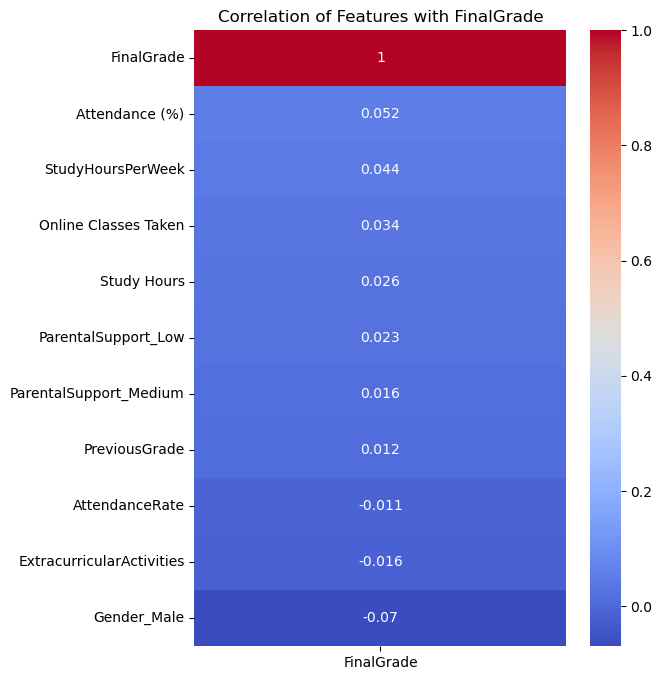

In [236]:
# First heatmap: makes it clear which features are most strongly correlated with the target (FinalGrade).

plt.figure(figsize=(6,8))
sns.heatmap(
    corr_matrix[['FinalGrade']].sort_values(by='FinalGrade', ascending=False),
    annot=True,          # show correlation values
    cmap="coolwarm"      # color scheme
)
plt.title("Correlation of Features with FinalGrade")
plt.show()


In [237]:
# Observation:
# The correlations between individual features and the target (FinalGrade) are weak.
# No single feature shows a strong linear relationship with the target.
# Therefore, we cannot rely on one feature alone for prediction.
# The model will need to combine information from multiple features
# to achieve meaningful performance.

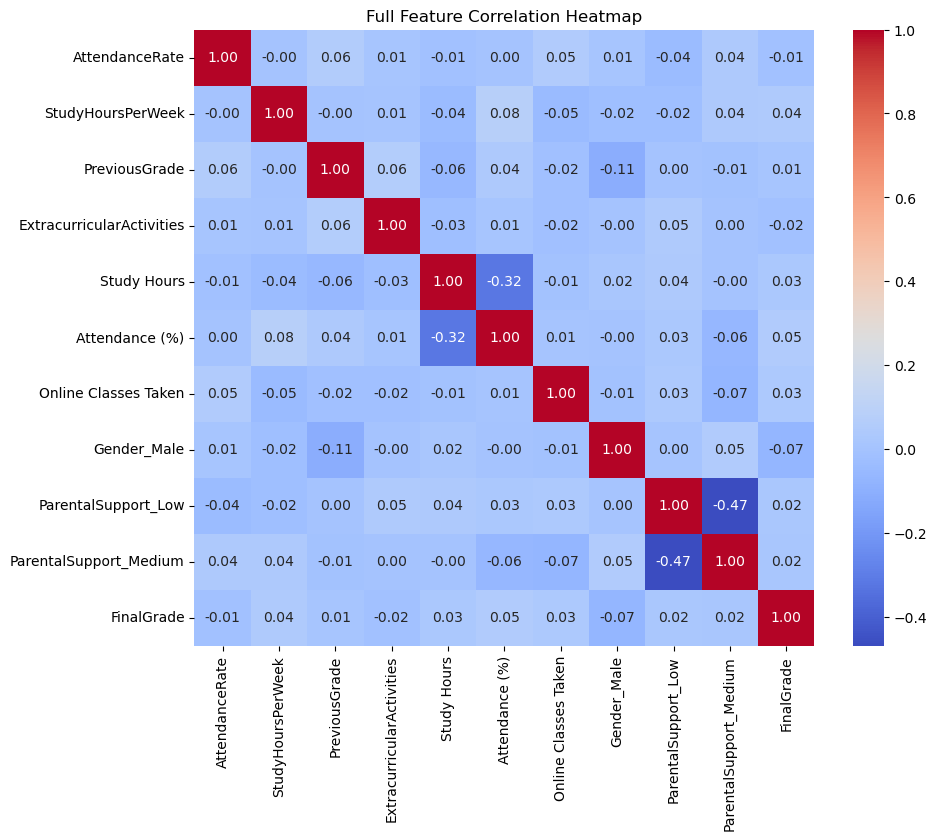

In [238]:
#Second heatmap: helps you see relationships between features themselves, so you can detect redundancy or multicollinearity.
#Redundancy = duplicated information.
#Multicollinearity = strong correlation between predictors that confuses the model.
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,          # show values inside cells
    fmt=".2f",           # format numbers to 2 decimals
    cmap="coolwarm"      # color scheme
)
plt.title("Full Feature Correlation Heatmap")
plt.show()

In [239]:
# Observations from Feature Correlation Heatmap:
# - Most correlations between features are weak (close to 0).
# - This means features are relatively independent and do not overlap much.
# - Strongest negative correlation: ParentalSupport_Low vs ParentalSupport_Medium (-0.47),
#   which makes sense since they represent opposite categories of the same variable.
# - AttendanceRate and Attendance (%) show only a very weak positive relation (~0.05),
#   so they are not redundant but still slightly related.
# - No major multicollinearity detected, which is good for models like linear regression.
# - Overall: features provide complementary information, so the model should benefit
#   from combining them rather than relying on one dominant predictor.